In [2]:
import pandas as pd
import os
from pathlib import Path
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

Tamaño de X_train: 35
Tamaño de y_train: 35
Coeficiente (pendiente): [0.97252801]
Intercepto: 11.987566619479267


C:\Users\ntrig\AppData\Local\Temp\ipykernel_19656\955951012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek'] + 4


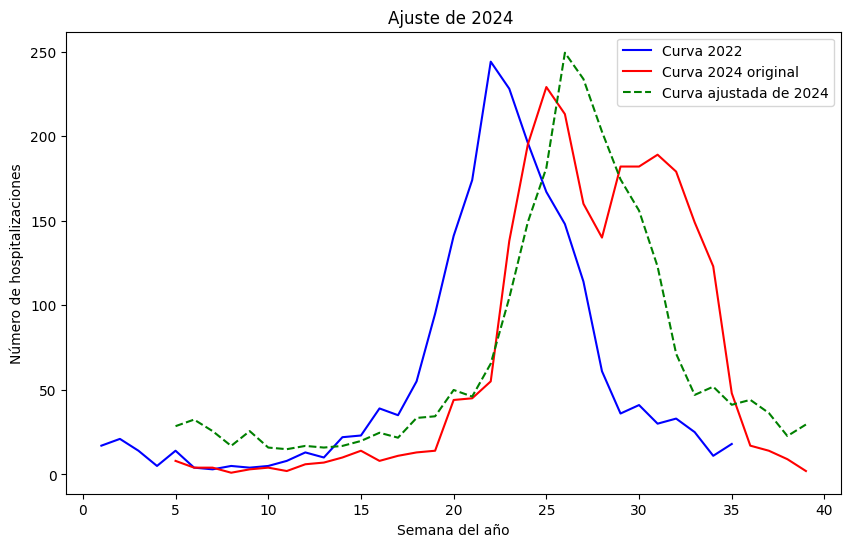

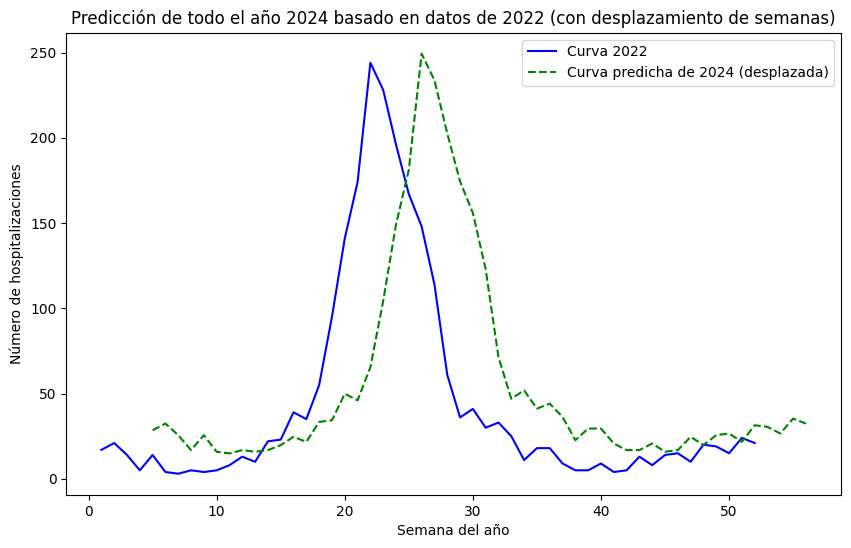

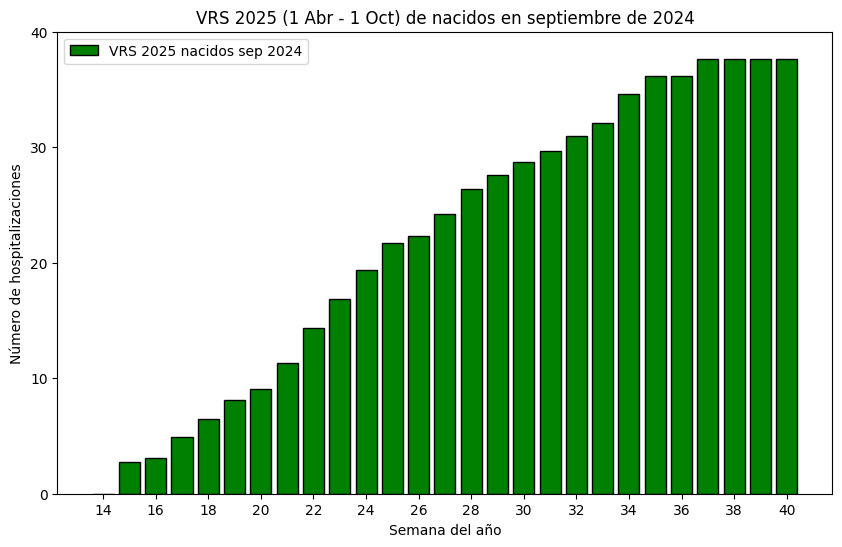

In [3]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df = pd.read_csv(path_data/"data.csv")
df = (df
      .drop(columns=['Unnamed: 0'])
      #.query('2021<=year | year<=2020')
      .assign(FECHA_NAC = pd.to_datetime(df['FECHA_NAC'], errors='coerce'),
              nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2022) & (x.FECHA_NAC.dt.month == 11), 1, 0),
              nac_sep=lambda x: np.where((x.FECHA_NAC.dt.year == 2021) & (x.FECHA_NAC.dt.month == 9), 1, 0))
      .copy()
)
regiones = df.region.unique()
hospitalizations_by_week = df.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
hospitalizations_by_week_elegibles = df.query('elegibilidad==year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
hospitalizations_by_week_non_elegibles = df.query('elegibilidad!=year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')

data = hospitalizations_by_week_non_elegibles.copy()

hospitalizations_2022 = data[data['year'] == 2022]

hospitalizations_2024 = data[data['year'] == 2024]

hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek'] + 4

epiweeks_2024 = hospitalizations_2024['epiweek'].unique()  
hospitalizations_2022_train = hospitalizations_2022[hospitalizations_2022['epiweek_shifted'].isin(epiweeks_2024)]  

hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2022_train['epiweek_shifted'])]

X_train = hospitalizations_2022_train['hospitalizations'].values.reshape(-1, 1)
y_train = hospitalizations_2024_train['hospitalizations'].values

print(f"Tamaño de X_train: {len(X_train)}")
print(f"Tamaño de y_train: {len(y_train)}")

model = LinearRegression()
model.fit(X_train, y_train)

coeficiente = model.coef_  
intercepto = model.intercept_  

print(f"Coeficiente (pendiente): {coeficiente}")
print(f"Intercepto: {intercepto}")

predicted_2024 = model.predict(X_train)

plt.figure(figsize=(10,6))

plt.plot(hospitalizations_2022_train['epiweek'], hospitalizations_2022_train['hospitalizations'], label='Curva 2022', color='blue')

plt.plot(hospitalizations_2024_train['epiweek'], hospitalizations_2024_train['hospitalizations'], label='Curva 2024 original', color='red')

plt.plot(hospitalizations_2022_train['epiweek_shifted'], predicted_2024, label='Curva ajustada de 2024', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Ajuste de 2024 ')
plt.legend()
plt.show()

hospitalizations_2022_full = data.query('year==2022').copy()

hospitalizations_2022_full['epiweek_shifted'] = hospitalizations_2022_full['epiweek'] + 4

# Usar las hospitalizaciones de 2022 desplazadas como entrada para predecir todo 2024
X_full = hospitalizations_2022_full['hospitalizations'].values.reshape(-1, 1)

# Predecir usando el modelo ya entrenado
predicted_2024_full = model.predict(X_full)

# Graficar las hospitalizaciones originales de 2022 y las predicciones para 2024
plt.figure(figsize=(10,6))

# Graficar las hospitalizaciones originales de 2022
plt.plot(hospitalizations_2022_full['epiweek'], hospitalizations_2022_full['hospitalizations'], label='Curva 2022', color='blue')

# Graficar las predicciones de 2024
plt.plot(hospitalizations_2022_full['epiweek_shifted'], predicted_2024_full, label='Curva predicha de 2024 (desplazada)', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Predicción de todo el año 2024 basado en datos de 2022 (con desplazamiento de semanas)')
plt.legend()

# Mostrar el gráfico
plt.show()
df_note = df.query('elegibilidad!=year')

hospitalizations_total = df_note.groupby(['year', 'epiweek']).size().reset_index(name='total_hospitalizations')

hospitalizations_sep = df_note[df_note['nac_sep'] == 1].groupby(['year', 'epiweek']).size().reset_index(name='sep_hosptialization')

hospitalizations = pd.merge(hospitalizations_total, hospitalizations_sep, on=['year', 'epiweek'], how='left')

hospitalizations['sep_hosptialization'] = hospitalizations['sep_hosptialization'].fillna(0)

hospitalizations['percentage_sep'] = (hospitalizations['sep_hosptialization'] / hospitalizations['total_hospitalizations']) * 100

hospitalizations_nov = df_note[df_note['nac_nov'] == 1].groupby(['year', 'epiweek']).size().reset_index(name='nov_hospitalizations')

hospitalizations = pd.merge(hospitalizations, hospitalizations_nov, on=['year', 'epiweek'], how='left')

hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)

hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['total_hospitalizations']) * 100
weeks_2024 = hospitalizations.query('year==2022')['epiweek'].unique() 

X_full = hospitalizations.query('year==2022')['sep_hosptialization'].values.reshape(-1, 1)

predicted_2024_full = model.predict(X_full)

predictions_df = pd.DataFrame({
    'epiweek': weeks_2024,
    'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
})

hospitalizations_merged = hospitalizations.query('year==2022').merge(predictions_df, on='epiweek', how='left')

hospitalizations_merged['predicted_sep_2024'] = (hospitalizations_merged['percentage_sep'] / 100) * hospitalizations_merged['predicted_2024']

hospitalizations_merged = hospitalizations_merged[['year', 'epiweek', 'total_hospitalizations', 'predicted_2024', 'percentage_sep', 'predicted_sep_2024']]


hospitalizations_filtered = hospitalizations_merged[(hospitalizations_merged['epiweek'] >= 14) & (hospitalizations_merged['epiweek'] <= 40)]


plt.figure(figsize=(10,6))


plt.bar(hospitalizations_filtered['epiweek'], hospitalizations_filtered['predicted_sep_2024'].cumsum(), color='green', edgecolor='black', label='VRS 2025 nacidos sep 2024')


plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('VRS 2025 (1 Abr - 1 Oct) de nacidos en septiembre de 2024')


plt.xticks(np.arange(14, 41, 2))
plt.yticks(np.arange(0, hospitalizations_filtered['predicted_sep_2024'].cumsum().max() + 10, 10))

plt.legend()

plt.show()


In [43]:
hospitalizations_total = (df
                          .groupby(['year', 'epiweek', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df
                        .query('nac_nov == 1')
                        .groupby(['year', 'epiweek', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
                        .copy()
)



max_cumsum_by_region = {}

for i in regiones:   
    # Procesar los datos y realizar el ajuste del modelo como en tu código original
    hospitalizations_reg = hospitalizations_total[['year', 'epiweek', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    hospitalizations_sep_reg = hospitalizations_nov[['year', 'epiweek',i]].copy().rename(columns = {i:'nov_hospitalizations'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_sep_reg, on=['year', 'epiweek'], how='left')
    hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)
    hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['regional_hospitalizations']) * 100

    hospitalizations = hospitalizations.assign(
        year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2022, x.year),
        epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
    ).copy()
    
    # Selección y entrenamiento del modelo
    hospitalizations_2019 = hospitalizations[hospitalizations['year'] == 2019]
    hospitalizations_2024 = hospitalizations[hospitalizations['year'] == 2024]
    epiweeks_2024 = hospitalizations_2024['epiweek'].unique() 
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek'].isin(epiweeks_2024)]  
    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek'])]
    
    X_train = hospitalizations_2019_train['regional_hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['regional_hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predicción para 2024 completa
    weeks_2024 = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))')['epiweek_ext'].unique() 
    X_full = hospitalizations.query('year_ext==2019')['regional_hospitalizations'].values.reshape(-1, 1)
    predicted_2024_full = model.predict(X_full)
    
    # Crear DataFrame con las predicciones y calcular cumsum
    predictions_df = pd.DataFrame({
        'epiweek_ext': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })
    hospitalizations_merged = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))').merge(predictions_df, on='epiweek_ext', how='left')
    hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']
    
    # Calcular el valor máximo de la curva acumulada para la región actual y almacenarlo
    max_cumsum_by_region[i] = hospitalizations_merged['predicted_nov_2024'].cumsum().max()

# Paso final: Crear el gráfico con los valores máximos de cumsum de cada región

plt.figure(figsize=(12, 6))

# Graficar las regiones en el eje x y sus valores máximos de cumsum en el eje y
plt.bar(max_cumsum_by_region.keys(), max_cumsum_by_region.values(), color='green', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en noviembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

UndefinedVariableError: name 'nac_nov' is not defined